# Module 4: Simulating the Detector Voltage Trace

---

In this module, we simulate what a real TDLAS detector would see: a voltage signal over time as the laser scans across the CH₄ absorption features.

**Learning Objectives:**
- Model the sinusoidal laser drive signal
- Build the nonlinear wavenumber-vs-time mapping ($d\nu/dt \propto |dV/dt|$)
- Compute transmitted intensity using Beer–Lambert: $I_t(t) = I_0(t) \cdot e^{-\alpha(t)}$
- Vectorize the simulation for speed (helps with generating 1M scans later)

**Prerequisites:** Module 3 complete (HITRAN data cached, `generate_absorbance_spectrum` working)

**Deliverable:** A complete simulated detector trace from any (T, P, $\chi$, L) input.

---

## Setup: Imports and HITRAN Initialization

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

# Import HAPI (installed in Module 1A / Module 3)
import hapi

# ── Project paths ──────────────────────────────────────────
PROJECT_DIR = Path.home() / "RedwoodLabs" / "methane-ml-course"
DATA_DIR    = PROJECT_DIR / 'data'
HITRAN_DIR  = DATA_DIR / 'hitran'
SPECTRA_DIR = DATA_DIR / 'spectra'
OUTPUT_DIR  = PROJECT_DIR / 'outputs'

for d in [DATA_DIR, HITRAN_DIR, SPECTRA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── HITRAN parameters ──────────────────────────────────────
MOLECULE_ID  = 6
ISOTOPE_ID   = 1
TABLE_NAME   = 'CH4_4383_4386'
NU_MIN       = 4383.0     # cm⁻¹
NU_MAX       = 4386.0     # cm⁻¹
NU_STEP      = 0.001      # cm⁻¹
PATH_LENGTH  = 100.0      # cm

# Initialize HITRAN database (uses cached data from Module 1A/3)
hapi.db_begin(str(HITRAN_DIR))

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11

print("✅ Setup complete!")

Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran

CH4_4383_4386
                     Lines parsed: 501
✅ Setup complete!


### Absorbance Generation Function (from Module 3)

We bring forward the `generate_absorbance_spectrum` function from Module 3. This is the physics engine that converts (T, P, $\chi$, L) into an absorbance spectrum using HITRAN line data.

In [20]:
def generate_absorbance_spectrum(T, P, xi, L=PATH_LENGTH,
                                  nu_min=NU_MIN, nu_max=NU_MAX, nu_step=NU_STEP):
    """
    Generate an absorbance spectrum for CH4 using HITRAN/HAPI.
    
    Parameters
    ----------
    T : float       Temperature (K)
    P : float       Pressure (atm)
    xi : float      Mole fraction (e.g. 0.01 = 10,000 ppm)
    L : float       Path length (cm)
    
    Returns
    -------
    nu : ndarray    Wavenumber grid (cm⁻¹)
    absorbance : ndarray   Absorbance (dimensionless)
    """
    nu, coef = hapi.absorptionCoefficient_Voigt(
        SourceTables=TABLE_NAME,
        Components=[(MOLECULE_ID, ISOTOPE_ID, xi)],
        Environment={'T': T, 'p': P},
        WavenumberRange=[nu_min, nu_max],
        WavenumberStep=nu_step,
        HITRAN_units=False
    )
    absorbance = coef * L
    return nu, absorbance

# Quick test
nu_test, a_test = generate_absorbance_spectrum(T=296, P=1.0, xi=0.01)
print(f"✅ Absorbance generator working: {len(nu_test)} points, peak α = {a_test.max():.4f}")

{'air': 1.0}
0.130177 seconds elapsed for abscoef; nlines = 501
✅ Absorbance generator working: 3001 points, peak α = 0.6911


---
## 4.1 — Modeling the Laser Drive Signal

In a real TDLAS system, the laser's injection current is modulated by a periodic voltage signal. This causes the laser to sweep across a range of wavelengths.

We model the drive voltage as a **sinusoid**:

$$V(t) = A \cos(2\pi f t) + \text{offset}$$

with voltage oscillating between $0 - 2$ V, giving an amplitude A = $1.0$ V and an offset of $= 1.0$ V.

**Why a sinusoid instead of a sawtooth or a triangular wave?**
A sinusoid makes the math and the simulation of the detector signal much simpler. It also simplifies the similated output wavelength of the laser. In practice, the output wavelength of the laser varies proportionally with changes in the scan input waveform. In this example, the scan frequency is only 10 Hz. In general this is a decent assumption. Once the scan frquency hits 1 kHz or greater, it would make sense to just measure the relative output wavelength of the laser as a function of time. This can be done with a Fabry-Perot etalon.

**Key parameters:**
- Scan rate: $f = 10$ Hz (10 full scans per second)
- Sample rate: 250 kHz (250,000 samples/s)
- Samples per scan: $250{,}000 / 10 = 25{,}000$

In [21]:
# ── Scan parameters ────────────────────────────────────────
f           = 10              # Hz — scan frequency
V_min       = 0.0             # V  — minimum drive voltage
V_max       = 2.0             # V  — maximum drive voltage
nu_min_scan = NU_MIN          # cm⁻¹ — wavenumber at V_min
nu_max_scan = NU_MAX          # cm⁻¹ — wavenumber at V_max
sample_rate = 250_000         # samples/s
duration    = 1 / f           # s — one full scan period

# ── Time array ─────────────────────────────────────────────
N_samples = int(sample_rate * duration)   # 25,000 samples per scan
t = np.linspace(0, duration, N_samples, endpoint=False)
dt = t[1] - t[0]

# ── Drive voltage: V(t) = A·cos(2πft) + offset ────────────
A = (V_max - V_min) / 2       # amplitude = 1 V
offset = (V_max + V_min) / 2  # offset = 1 V
V_drive = A * np.cos(2 * np.pi * f * t) + offset

print(f"Scan frequency : {f} Hz")
print(f"Sample rate    : {sample_rate:,} Hz")
print(f"Samples/scan   : {N_samples:,}")
print(f"Time step (dt) : {dt*1e6:.2f} µs")
print(f"V range        : [{V_drive.min():.1f}, {V_drive.max():.1f}] V")

Scan frequency : 10 Hz
Sample rate    : 250,000 Hz
Samples/scan   : 25,000
Time step (dt) : 4.00 µs
V range        : [0.0, 2.0] V


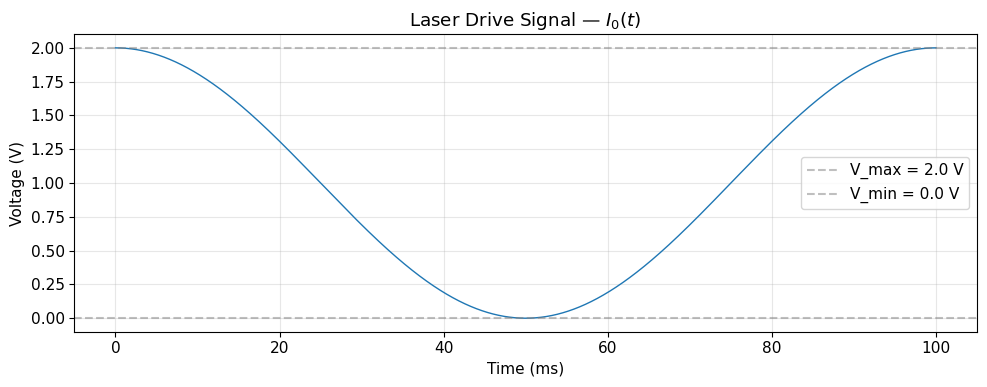

The cosine starts at V_max (t=0), drops to V_min at the half-period,
and returns to V_max — this drives the laser through one complete scan cycle.


In [22]:
# Plot the drive signal — this is I₀(t), the incident intensity on the detector
plt.figure(figsize=(10, 4))
plt.plot(t * 1e3, V_drive, color='tab:blue', linewidth=1)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('Laser Drive Signal — $I_0(t)$')
plt.grid(True, alpha=0.3)
plt.axhline(y=V_max, color='gray', linestyle='--', alpha=0.5, label=f'V_max = {V_max} V')
plt.axhline(y=V_min, color='gray', linestyle='--', alpha=0.5, label=f'V_min = {V_min} V')
plt.legend()
plt.tight_layout()
plt.show()

print("The cosine starts at V_max (t=0), drops to V_min at the half-period,")
print("and returns to V_max — this drives the laser through one complete scan cycle.")

---
## 4.2 — Mapping Voltage to Wavenumber Over Time

### The Key Assumption: $d\nu/dt \propto |dV/dt|$

The laser's wavenumber tracks the drive voltage, but the relationship is governed by the **rate of change** of voltage, not the voltage itself. Since $V(t) = \cos(2\pi f t)$, we have:

$$\frac{dV}{dt} \propto -\sin(2\pi f t)$$

The speed at which the laser tunes through wavenumber space is proportional to $|\sin(2\pi f t)|$. This means:
- The scan moves **fastest** at the mid-voltage (where $|dV/dt|$ is maximum)
- The scan moves **slowest** near the voltage extremes (where $dV/dt \approx 0$)

### The Scan Path

One full period produces a there-and-back scan:

$$\nu_{\max} \xrightarrow{\text{1st half}} \nu_{\min} \xrightarrow{\text{2nd half}} \nu_{\max}$$

We build $\nu(t)$ by using the cumulative $|\sin|$ weighting as a nonlinear progress variable.

In [23]:
def build_nu_scan(t, f, nu_min_scan, nu_max_scan):
    """
    Build the nonlinear wavenumber-vs-time mapping for a sinusoidal scan.
    
    The wavenumber sweep rate is proportional to |dV/dt| = |sin(2πft)|.
    We compute a cumulative progress variable from this weighting,
    separately for the down-sweep and up-sweep halves.
    
    Parameters
    ----------
    t : ndarray          Time array for one full period
    f : float            Scan frequency (Hz)
    nu_min_scan : float  Minimum wavenumber (cm⁻¹)
    nu_max_scan : float  Maximum wavenumber (cm⁻¹)
    
    Returns
    -------
    nu_scan : ndarray    Wavenumber at each time sample
    """
    N = len(t)
    N1 = N // 2  # half-period index
    dt = t[1] - t[0]
    
    def half_progress(times):
        """Compute normalized cumulative progress from |sin| weighting."""
        midpoints = times[:-1] + dt / 2
        weights = np.abs(np.sin(2 * np.pi * f * midpoints))
        cumulative = np.concatenate([[0.0], np.cumsum(weights)])
        if cumulative[-1] != 0:
            return cumulative / cumulative[-1]
        else:
            return np.linspace(0, 1, len(times))
    
    # Down-sweep: ν_max → ν_min (first half of cosine: V goes from max to min)
    p_down = half_progress(t[:N1])
    nu_down = nu_max_scan - (nu_max_scan - nu_min_scan) * p_down
    
    # Up-sweep: ν_min → ν_max (second half of cosine: V goes from min to max)
    p_up = half_progress(t[N1:])
    nu_up = nu_min_scan + (nu_max_scan - nu_min_scan) * p_up
    
    nu_scan = np.concatenate([nu_down, nu_up])
    
    # Force exact endpoints
    nu_scan[0]      = nu_max_scan
    nu_scan[N1 - 1] = nu_min_scan
    nu_scan[-1]     = nu_max_scan
    
    return nu_scan

# Build ν(t)
nu_scan = build_nu_scan(t, f, nu_min_scan, nu_max_scan)

print(f"ν range: [{nu_scan.min():.3f}, {nu_scan.max():.3f}] cm⁻¹")
print(f"✅ Wavenumber mapping built: {len(nu_scan):,} points")

ν range: [4383.000, 4386.000] cm⁻¹
✅ Wavenumber mapping built: 25,000 points


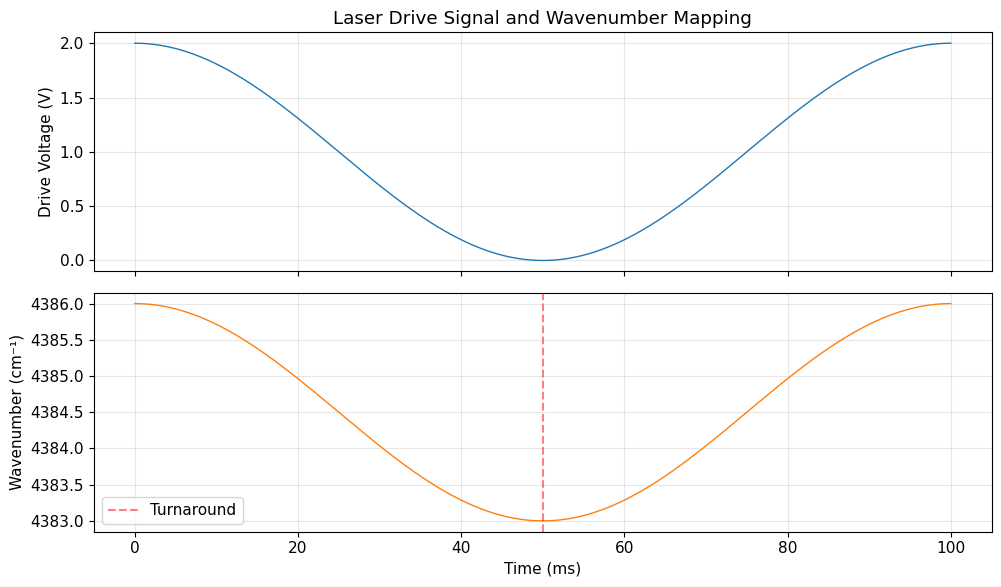

In [24]:
# Plot ν vs time alongside V(t)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t * 1e3, V_drive, color='tab:blue', linewidth=1)
axes[0].set_ylabel('Drive Voltage (V)')
axes[0].set_title('Laser Drive Signal and Wavenumber Mapping')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t * 1e3, nu_scan, color='tab:orange', linewidth=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Wavenumber (cm⁻¹)')
axes[1].grid(True, alpha=0.3)

# Mark the turnaround point
N1 = N_samples // 2
axes[1].axvline(x=t[N1]*1e3, color='red', linestyle='--', alpha=0.5, label='Turnaround')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4.3 — Computing Transmitted Intensity

Now we put it all together. For a given set of physical conditions (T, P, $\chi$):

1. **Generate the absorbance spectrum** $\alpha(\nu)$ using HITRAN (Module 3)
2. **Look up** $\alpha$ at each $\nu(t)$ along the scan path
3. **Apply Beer–Lambert**: $I_t(t) = I_0(t) \cdot e^{-\alpha(t)}$

The lookup uses nearest-neighbor interpolation: for each $\nu(t)$ sample, we find the closest point in the HITRAN-generated spectrum. 

In [25]:
def simulate_detector_scan(T, P, xi, L=PATH_LENGTH, f=10, V_min=0.0, V_max=2.0,
                           nu_min_scan=NU_MIN, nu_max_scan=NU_MAX,
                           sample_rate=250_000):
    """
    Simulate a complete TDLAS detector voltage trace.
    
    This is the full forward model:
        (T, P, χ) → HITRAN absorbance → scan mapping → detector voltage
    
    Parameters
    ----------
    T : float           Temperature (K)
    P : float           Pressure (atm)
    xi : float          Mole fraction (e.g. 0.01 = 10,000 ppm)
    L : float           Path length (cm)
    f : float           Scan frequency (Hz)
    V_min, V_max : float   Drive voltage range (V)
    nu_min_scan, nu_max_scan : float   Wavenumber scan range (cm⁻¹)
    sample_rate : int   Samples per second
    
    Returns
    -------
    result : dict with keys:
        't'        : ndarray — time array (s)
        'I_0'      : ndarray — incident intensity / drive voltage (V)
        'I_t'      : ndarray — transmitted intensity (V)
        'nu_scan'  : ndarray — wavenumber at each time step (cm⁻¹)
        'alpha_t'  : ndarray — absorbance at each time step
        'nu_spec'  : ndarray — HITRAN wavenumber grid
        'alpha_spec': ndarray — HITRAN absorbance spectrum
    """
    duration = 1 / f
    N = int(sample_rate * duration)
    
    # ── Time and drive signal ──────────────────────────────
    t = np.linspace(0, duration, N, endpoint=False)
    A_drive = (V_max - V_min) / 2
    offset = (V_max + V_min) / 2
    I_0 = A_drive * np.cos(2 * np.pi * f * t) + offset
    
    # ── Wavenumber mapping ─────────────────────────────────
    nu_scan = build_nu_scan(t, f, nu_min_scan, nu_max_scan)
    
    # ── Generate absorbance spectrum from HITRAN ───────────
    nu_spec, alpha_spec = generate_absorbance_spectrum(
        T, P, xi, L,
        nu_min=nu_min_scan, nu_max=nu_max_scan, nu_step=NU_STEP
    )
    
    # ── Nearest-neighbor lookup (loop version) ─────────────
    # This is the quick approach — we'll vectorize in Section 4.4
    alpha_t = np.zeros(N)
    for i, nu_val in enumerate(nu_scan):
        idx = np.argmin(np.abs(nu_spec - nu_val))
        alpha_t[i] = alpha_spec[idx]
    
    # ── Beer–Lambert: transmitted intensity ────────────────
    I_t = I_0 * np.exp(-alpha_t)
    
    return {
        't': t, 'I_0': I_0, 'I_t': I_t,
        'nu_scan': nu_scan, 'alpha_t': alpha_t,
        'nu_spec': nu_spec, 'alpha_spec': alpha_spec
    }

print("✅ simulate_detector_scan() defined")
print("   (using quick for-loop lookup — vectorized version coming in 4.4)")

✅ simulate_detector_scan() defined
   (using quick for-loop lookup — vectorized version coming in 4.4)


In [26]:
# ── Run the simulation at reference conditions ─────────────
T_demo, P_demo, xi_demo = 296, 1.0, 0.01   # 10,000 ppm at standard conditions

print(f"Simulating detector scan...")
print(f"  T = {T_demo} K, P = {P_demo} atm, χ = {xi_demo} ({xi_demo*1e6:.0f} ppm)")

t0 = time.time()
result = simulate_detector_scan(T_demo, P_demo, xi_demo)
elapsed = time.time() - t0

print(f"\n✅ Simulation complete in {elapsed:.2f}s")
print(f"   Samples: {len(result['t']):,}")
print(f"   Peak absorbance: {result['alpha_t'].max():.4f}")

Simulating detector scan...
  T = 296 K, P = 1.0 atm, χ = 0.01 (10000 ppm)
{'air': 1.0}
0.132739 seconds elapsed for abscoef; nlines = 501

✅ Simulation complete in 0.23s
   Samples: 25,000
   Peak absorbance: 0.6911


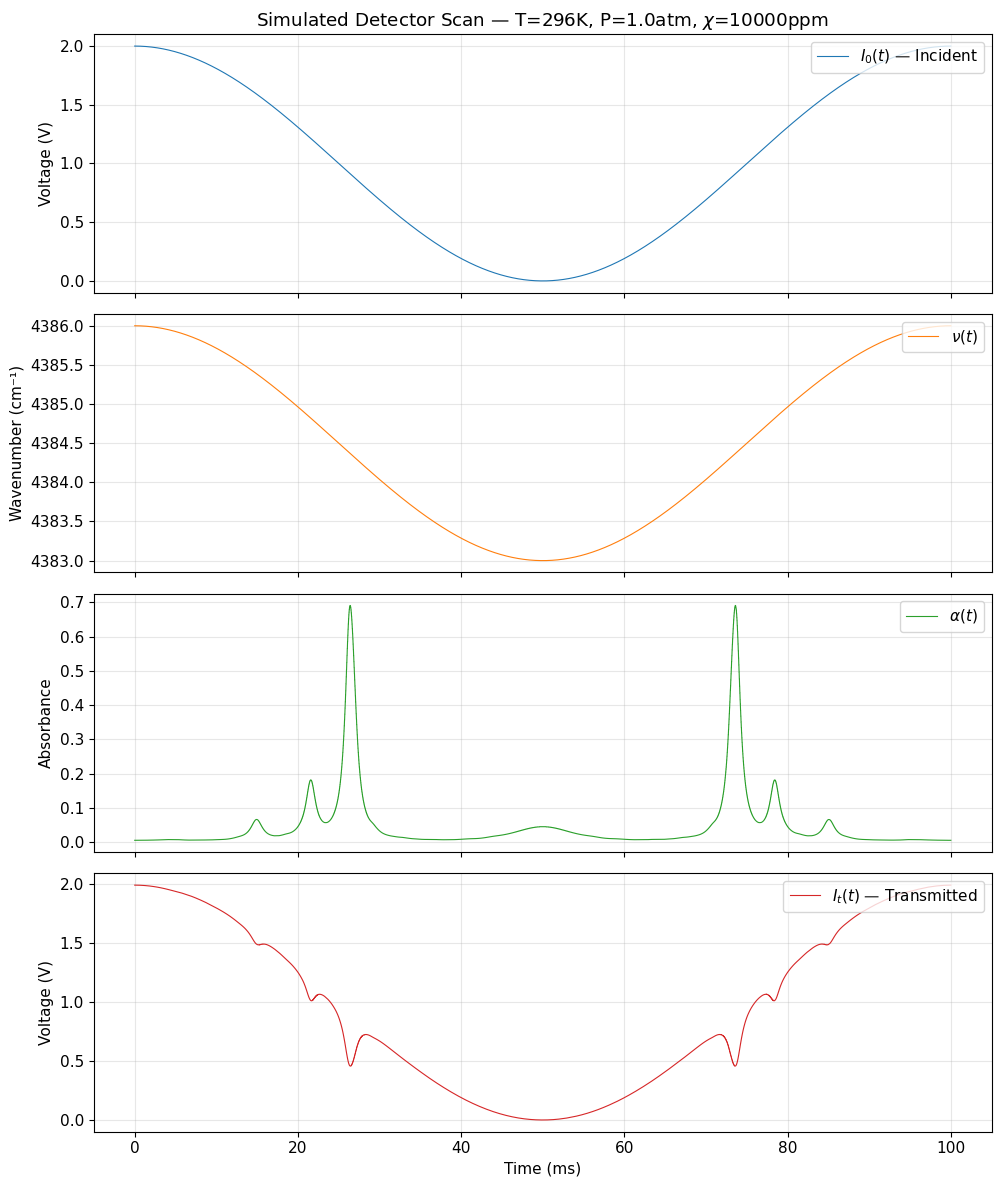

The bottom trace (I_t) is what a real photodetector would produce.
The absorption dips appear TWICE — once on the down-sweep, once on the up-sweep.


In [27]:
# ── Plot all four traces ───────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

t_ms = result['t'] * 1e3  # convert to ms for display

# 1) I₀ vs time
axes[0].plot(t_ms, result['I_0'], color='tab:blue', linewidth=0.8)
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title(f'Simulated Detector Scan — T={T_demo}K, P={P_demo}atm, $\\chi$={xi_demo*1e6:.0f}ppm')
axes[0].legend(['$I_0(t)$ — Incident'], loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2) ν vs time
axes[1].plot(t_ms, result['nu_scan'], color='tab:orange', linewidth=0.8)
axes[1].set_ylabel('Wavenumber (cm⁻¹)')
axes[1].legend(['$\\nu(t)$'], loc='upper right')
axes[1].grid(True, alpha=0.3)

# 3) Absorbance vs time
axes[2].plot(t_ms, result['alpha_t'], color='tab:green', linewidth=0.8)
axes[2].set_ylabel('Absorbance')
axes[2].legend(['$\\alpha(t)$'], loc='upper right')
axes[2].grid(True, alpha=0.3)

# 4) I_t vs time — this is what the detector actually measures!
axes[3].plot(t_ms, result['I_t'], color='tab:red', linewidth=0.8)
axes[3].set_xlabel('Time (ms)')
axes[3].set_ylabel('Voltage (V)')
axes[3].legend(['$I_t(t)$ — Transmitted'], loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The bottom trace (I_t) is what a real photodetector would produce.")
print("The absorption dips appear TWICE — once on the down-sweep, once on the up-sweep.")

### The "Doubled Trace" — Absorbance vs Wavelength Along the Scan Path

Because the laser scans $\nu_{\max} \to \nu_{\min} \to \nu_{\max}$, the absorption features appear **twice** in the time-domain signal. We can visualize this by plotting absorbance vs wavelength in scan order.

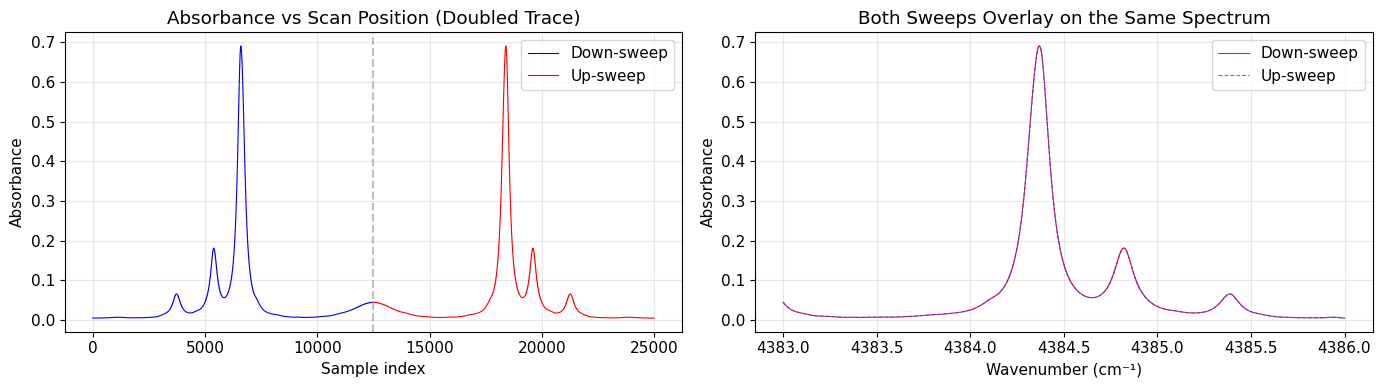

Left: The CNN sees this doubled pattern in the time domain.
Right: Both sweeps trace the same underlying absorbance spectrum.


In [28]:
# Plot absorbance along the scan path with wavelength labels
N1 = N_samples // 2
lambda_scan = 1e7 / result['nu_scan']  # convert to nm

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Absorbance vs scan index (showing the doubled trace)
x_scan = np.arange(N_samples)
axes[0].plot(x_scan[:N1], result['alpha_t'][:N1], 'b-', linewidth=0.8, label='Down-sweep')
axes[0].plot(x_scan[N1:], result['alpha_t'][N1:], 'r-', linewidth=0.8, label='Up-sweep')
axes[0].axvline(x=N1, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Absorbance')
axes[0].set_title('Absorbance vs Scan Position (Doubled Trace)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Absorbance vs wavenumber (un-folded — both sweeps overlay)
axes[1].plot(result['nu_scan'][:N1], result['alpha_t'][:N1], 'b-',
             linewidth=0.8, alpha=0.7, label='Down-sweep')
axes[1].plot(result['nu_scan'][N1:], result['alpha_t'][N1:], 'r--',
             linewidth=0.8, alpha=0.7, label='Up-sweep')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Absorbance')
axes[1].set_title('Both Sweeps Overlay on the Same Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: The CNN sees this doubled pattern in the time domain.")
print("Right: Both sweeps trace the same underlying absorbance spectrum.")

---
## 4.4 — Vectorizing the Simulation for Speed

The quick for-loop lookup in Section 4.3 works, but it's painfully slow — about 25,000 calls to `np.argmin` per scan. Since we'll need to generate **1 million scans** in Module 5, we need to vectorize this.

### Strategy: `np.searchsorted`

Since the HITRAN wavenumber grid is uniformly spaced and sorted, we can use `np.searchsorted` for $O(\log n)$ lookup instead of $O(n)$ per point. Even better, because the grid is uniform, we can compute indices directly with arithmetic.

### Vectorized Approach

For a uniform grid with spacing $\Delta\nu$ starting at $\nu_{\min}$:

$$\text{index} = \text{round}\!\left(\frac{\nu - \nu_{\min}}{\Delta\nu}\right)$$

Then clip to valid range.

In [30]:
def simulate_detector_scan_fast(T, P, xi, L=PATH_LENGTH, f=10, V_min=0.0, V_max=2.0,
                                 nu_min_scan=NU_MIN, nu_max_scan=NU_MAX,
                                 sample_rate=250_000):
    """
    Vectorized version of simulate_detector_scan().
    
    Replaces the Python for-loop with vectorized index computation
    Returns the same dict as simulate_detector_scan().
    """
    duration = 1 / f
    N = int(sample_rate * duration)
    
    # ── Time and drive signal ──────────────────────────────
    t = np.linspace(0, duration, N, endpoint=False)
    A_drive = (V_max - V_min) / 2
    offset = (V_max + V_min) / 2
    I_0 = A_drive * np.cos(2 * np.pi * f * t) + offset
    
    # ── Wavenumber mapping ─────────────────────────────────
    nu_scan = build_nu_scan(t, f, nu_min_scan, nu_max_scan)
    
    # ── Generate absorbance spectrum from HITRAN ───────────
    nu_spec, alpha_spec = generate_absorbance_spectrum(
        T, P, xi, L,
        nu_min=nu_min_scan, nu_max=nu_max_scan, nu_step=NU_STEP
    )
    
    # ── VECTORIZED nearest-neighbor lookup ─────────────────
    # The HITRAN grid is uniform: nu_spec = nu_min, nu_min+step, nu_min+2*step, ...
    # So we can compute indices directly:
    indices = np.round((nu_scan - nu_spec[0]) / NU_STEP).astype(int)
    indices = np.clip(indices, 0, len(alpha_spec) - 1)
    alpha_t = alpha_spec[indices]
    
    # ── Beer–Lambert ───────────────────────────────────────
    I_t = I_0 * np.exp(-alpha_t)
    
    return {
        't': t, 'I_0': I_0, 'I_t': I_t,
        'nu_scan': nu_scan, 'alpha_t': alpha_t,
        'nu_spec': nu_spec, 'alpha_spec': alpha_spec
    }

print("✅ simulate_detector_scan_fast() defined")

✅ simulate_detector_scan_fast() defined


In [31]:
# ── Timing comparison ──────────────────────────────────────
print("Timing comparison: loop vs. vectorized")
print("=" * 50)

# Quick loop version
t0 = time.time()
r_loop = simulate_detector_scan(296, 1.0, 0.01)
time_loop = time.time() - t0
print(f"Loop version     : {time_loop:.3f}s")

# Vectorized version
t0 = time.time()
r_vec = simulate_detector_scan_fast(296, 1.0, 0.01)
time_vec = time.time() - t0
print(f"Vectorized       : {time_vec:.3f}s")

speedup = time_loop / time_vec if time_vec > 0 else float('inf')
print(f"Speedup          : {speedup:.1f}x")

# Verify they produce the same result
max_diff = np.max(np.abs(r_loop['alpha_t'] - r_vec['alpha_t']))
print(f"\nMax difference   : {max_diff:.2e}")
print(f"✅ Results match!" if max_diff < 1e-10 else f"⚠️  Results differ by {max_diff}")

Timing comparison: loop vs. vectorized
{'air': 1.0}
0.133420 seconds elapsed for abscoef; nlines = 501
Loop version     : 0.228s
{'air': 1.0}
0.089099 seconds elapsed for abscoef; nlines = 501
Vectorized       : 0.090s
Speedup          : 2.5x

Max difference   : 0.00e+00
✅ Results match!


In [32]:
# ── Project what 1M scans would take ──────────────────────
N_target = 1_000_000
est_loop = time_loop * N_target
est_vec  = time_vec * N_target

print(f"Estimated time for {N_target:,} scans:")
print(f"  Loop version     : {est_loop/3600:.1f} hours")
print(f"  Vectorized       : {est_vec/3600:.1f} hours")
print(f"\n(Module 5 will further optimize with multiprocessing.)")

Estimated time for 1,000,000 scans:
  Loop version     : 63.3 hours
  Vectorized       : 24.9 hours

(Module 5 will further optimize with multiprocessing.)


---
## End-to-End Demo: Any (T, P, $\chi$) → Detector Trace

Let's package this into a clean demo function that takes arbitrary physical conditions and produces the detector output.

In [33]:
def demo_detector_trace(T, P, xi_ppm):
    """
    End-to-end demo: physical conditions → detector voltage trace.
    
    Parameters
    ----------
    T : float       Temperature (K)
    P : float       Pressure (atm)
    xi_ppm : float  Mole fraction in ppm
    """
    xi = xi_ppm / 1e6
    
    print(f"Input conditions:")
    print(f"  Temperature : {T} K ({T-273:.0f}°C)")
    print(f"  Pressure    : {P} atm")
    print(f"  Mole fraction: {xi_ppm:,.0f} ppm ({xi:.4%})")
    print(f"  Path length : {PATH_LENGTH} cm")
    print()
    
    # Run simulation
    t0 = time.time()
    r = simulate_detector_scan_fast(T, P, xi)
    elapsed = time.time() - t0
    
    # Plot: 2-panel — I₀ and I_t overlaid, plus absorbance spectrum
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    
    t_ms = r['t'] * 1e3
    
    # Top: Detector signals
    axes[0].plot(t_ms, r['I_0'], 'b-', linewidth=0.8, alpha=0.5, label='$I_0$ (baseline)')
    axes[0].plot(t_ms, r['I_t'], 'r-', linewidth=0.8, label='$I_t$ (transmitted)')
    axes[0].fill_between(t_ms, r['I_t'], r['I_0'], alpha=0.15, color='red')
    axes[0].set_ylabel('Detector Voltage (V)')
    axes[0].set_title(
        f'Simulated Detector Output\n'
        f'T = {T}K | P = {P}atm | $\\chi$ = {xi_ppm:,.0f}ppm'
    )
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Bottom: Absorbance spectrum (from HITRAN)
    axes[1].plot(r['nu_spec'], r['alpha_spec'], 'g-', linewidth=1)
    axes[1].set_xlabel('Wavenumber (cm⁻¹)')
    axes[1].set_ylabel('Absorbance')
    axes[1].set_title('Underlying HITRAN Absorbance Spectrum')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Simulation time: {elapsed:.3f}s")
    print(f"Peak absorbance: {r['alpha_t'].max():.4f}")
    print(f"Min I_t/I_0    : {(r['I_t']/r['I_0']).min():.4f} (transmittance at strongest line)")
    
    return r

Input conditions:
  Temperature : 296 K (23°C)
  Pressure    : 1.0 atm
  Mole fraction: 10,000 ppm (1.0000%)
  Path length : 100.0 cm

{'air': 1.0}
0.130938 seconds elapsed for abscoef; nlines = 501


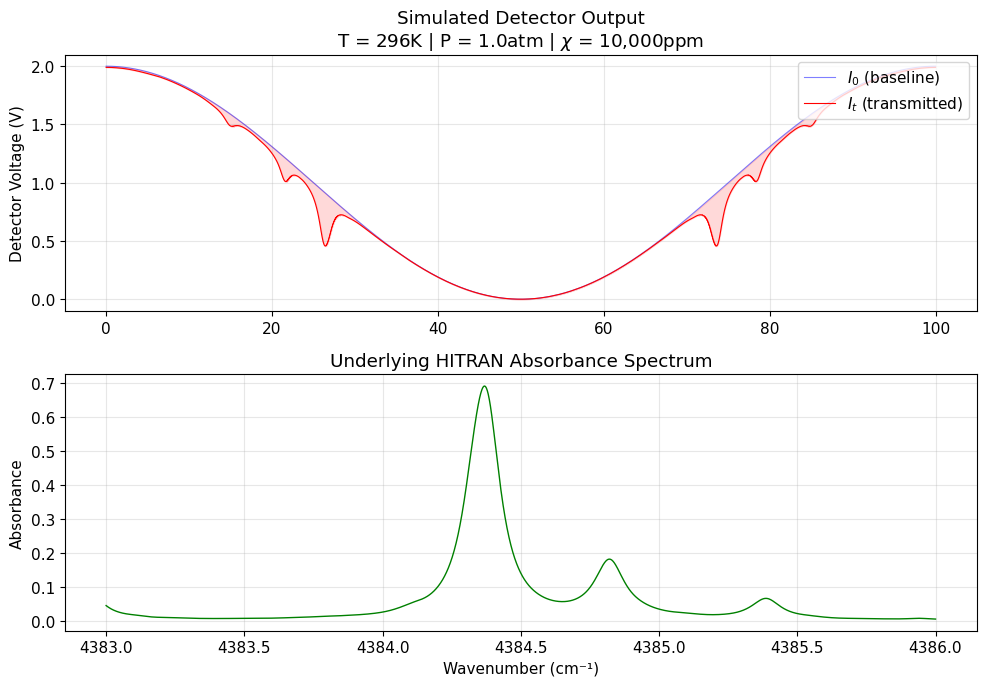

Simulation time: 0.134s
Peak absorbance: 0.6911
Min I_t/I_0    : nan (transmittance at strongest line)


/var/folders/qf/8yv_2y3x1bj5kkt_56_sxckm0000gn/T/ipykernel_10823/375503986.py:54: RuntimeWarning: invalid value encountered in divide
  print(f"Min I_t/I_0    : {(r['I_t']/r['I_0']).min():.4f} (transmittance at strongest line)")


In [34]:
# ── Demo 1: Standard conditions, moderate concentration ────
_ = demo_detector_trace(T=296, P=1.0, xi_ppm=10_000)

Input conditions:
  Temperature : 296 K (23°C)
  Pressure    : 1.0 atm
  Mole fraction: 500 ppm (0.0500%)
  Path length : 100.0 cm

{'air': 1.0}
0.146469 seconds elapsed for abscoef; nlines = 501


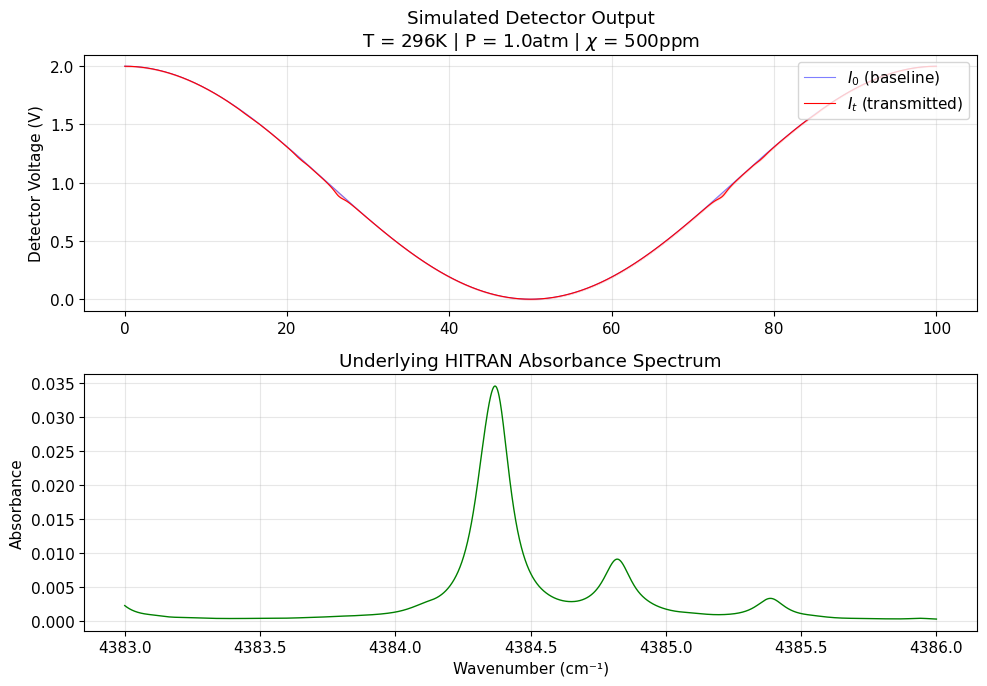

Simulation time: 0.149s
Peak absorbance: 0.0346
Min I_t/I_0    : nan (transmittance at strongest line)


/var/folders/qf/8yv_2y3x1bj5kkt_56_sxckm0000gn/T/ipykernel_10823/375503986.py:54: RuntimeWarning: invalid value encountered in divide
  print(f"Min I_t/I_0    : {(r['I_t']/r['I_0']).min():.4f} (transmittance at strongest line)")


In [35]:
# ── Demo 2: Low concentration (should see very small dips) ─
_ = demo_detector_trace(T=296, P=1.0, xi_ppm=500)

---
## Saving a Simulated Scan to CSV

For reference or debugging, you can save a simulated detector trace. The CSV contains time, $I_0$, $I_t$, $\nu$, and $\alpha$ columns.

In [36]:
def save_scan_csv(result, T, P, xi_ppm, output_dir=None):
    """
    Save a simulated detector scan to CSV.
    
    Filename: scan_TTT-P_P-XXXXX.csv
    """
    if output_dir is None:
        output_dir = SPECTRA_DIR
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    P_str = f"{P:.1f}".replace('.', '_')
    filename = f"scan_{int(T):03d}-{P_str}-{int(xi_ppm):05d}.csv"
    filepath = output_dir / filename
    
    header = (
        f"# Simulated TDLAS Detector Scan\n"
        f"# T={T}K, P={P}atm, xi={xi_ppm}ppm, L={PATH_LENGTH}cm\n"
        f"# f={10}Hz, sample_rate={250000}Hz\n"
        f"time_s,I0_V,It_V,nu_cm-1,absorbance"
    )
    
    data = np.column_stack([
        result['t'], result['I_0'], result['I_t'],
        result['nu_scan'], result['alpha_t']
    ])
    
    np.savetxt(filepath, data, delimiter=',', header=header, comments='')
    print(f"Saved: {filepath}")
    print(f"  Size: {filepath.stat().st_size / 1e6:.1f} MB")
    return filepath

# Save the reference scan
r_ref = simulate_detector_scan_fast(T=296, P=1.0, xi=0.01)
save_scan_csv(r_ref, T=296, P=1.0, xi_ppm=10_000)

{'air': 1.0}
0.127406 seconds elapsed for abscoef; nlines = 501
Saved: /Users/davidvs/RedwoodLabs/methane-ml-course/data/spectra/scan_296-1_0-10000.csv
  Size: 3.1 MB


PosixPath('/Users/davidvs/RedwoodLabs/methane-ml-course/data/spectra/scan_296-1_0-10000.csv')

---
## Summary

### What We Accomplished

1. **Modeled the laser drive** — Sinusoidal $V(t)$ between 0–2 V at 10 Hz
2. **Built the $\nu(t)$ mapping** — Nonlinear wavenumber sweep using cumulative $|\sin|$ weighting
3. **Computed $I_t(t)$** — Full Beer–Lambert: HITRAN absorbance → nearest-neighbor lookup → $I_0 \cdot e^{-\alpha}$
4. **Vectorized the lookup** — Replaced 25,000-iteration for-loop with direct index computation

### The Forward Model

```
(T, P, χ)  →  HITRAN α(ν)  →  ν(t) mapping  →  I_t(t) = I₀(t) · exp(-α(t))
```

### Key Functions

```python
# Fast simulation — use this one
result = simulate_detector_scan_fast(T=296, P=1.0, xi=0.01)

# Access results
result['t']       # time array
result['I_t']     # transmitted intensity (what the CNN sees)
result['I_0']     # incident intensity (baseline)
result['alpha_t'] # absorbance along scan path
result['nu_scan'] # wavenumber at each time step
```

### What's Next

In **Module 5**, we'll use `simulate_detector_scan_fast()` to generate **1 million scans** across the full parameter space:
- T: 253–323 K
- P: 0.8–1.1 atm  
- χ: 1–50,000 ppm

We'll parallelize with multiprocessing and store everything in an HDF5 file for efficient training.

---
**Module 4 Complete!**

You can now simulate a complete TDLAS detector voltage trace from any (T, P, $\chi$, L) input. This is the forward model that will generate 1 million training samples in Module 5.